# Convolution Tutorial Series — Part 1: Kernel Size and Bias

**Goal:** Understand how a 3x3 kernel functions as a 'stencil' to solve ARC tasks. This is the first episode in a series that we want to create, covering all the attributes of the ONNX Conv function, in this notebook we will cover the basics of the convolution. We will explain these as simply as possible, using some tasks as examples, similar to this [notebook](https://www.kaggle.com/code/massimilianoghiotto/best-public-6066-58-eda-111) that we made and EDA notebooks made by @cdeotte.

**Task (ARC 015):** 
1. **Red (2) triggers Yellow (4):** Every Red pixel should have Yellow pixels at its 4 diagonals (corners).
2. **Blue (1) triggers Orange (7):** Every Blue pixel should have Orange pixels at its Top, Bottom, Left, and Right (cross shape).
3. **Persistence:** The original Red and Blue pixels must stay.

**Score formula:** `Points = max(1.0, 25.0 - log(Mem_bytes + Params))`

**Our result:** Mem=0, Params=900, **18.198 points**

---

In [1]:
!pip install -q numpy==2.4.4 2>/dev/null
!pip install -q onnx==1.21.0 2>/dev/null
!pip install -q onnxruntime==1.24.4 2>/dev/null
!pip install -q onnx-tool==1.0.1 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 3.1 MB/s eta 0:00:00


# 1. Task 015

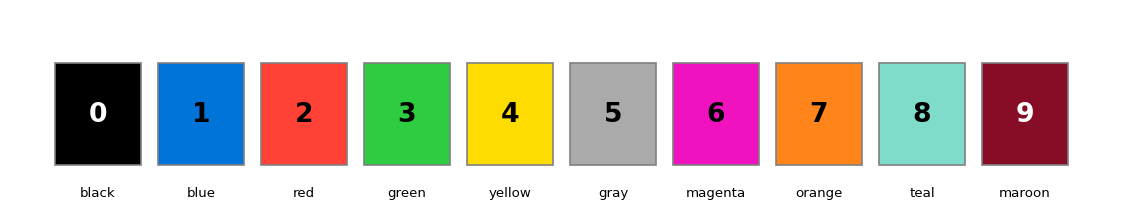

In [2]:
import json, math, warnings, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import onnx
from onnx import helper, TensorProto
import onnxruntime as ort

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

arc_colors = [
    '#000000',  # 0: black
    '#0074D9',  # 1: blue
    '#FF4136',  # 2: red
    '#2ECC40',  # 3: green
    '#FFDC00',  # 4: yellow
    '#AAAAAA',  # 5: gray
    '#F012BE',  # 6: magenta
    '#FF851B',  # 7: orange
    '#7FDBCA',  # 8: teal
    '#870C25',  # 9: maroon
]
color_names = ['black','blue','red','green','yellow','gray','magenta','orange','teal','maroon']

def plot_arc_grid(grid, ax, title=''):
    H, W = len(grid), len(grid[0])
    img = np.zeros((H, W, 3), dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            hex_c = arc_colors[grid[r][c]].lstrip('#')
            img[r,c] = [int(hex_c[i:i+2], 16) for i in (0, 2, 4)]
    ax.imshow(img, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title, fontsize=10, fontweight='bold')
    for r in range(H+1): ax.axhline(r-0.5, color='gray', lw=0.5, alpha=0.3)
    for c in range(W+1): ax.axvline(c-0.5, color='gray', lw=0.5, alpha=0.3)

fig, ax = plt.subplots(figsize=(12, 2))
for i, (c, nm) in enumerate(zip(arc_colors, color_names)):
    ax.add_patch(patches.Rectangle((i*1.2, 0), 1, 1, facecolor=c, edgecolor='gray', lw=1))
    ax.text(i*1.2+0.5, 0.5, str(i), ha='center', va='center', fontsize=16, fontweight='bold',
            color='white' if i in [0,9] else 'black')
    ax.text(i*1.2+0.5, -0.2, nm, ha='center', va='top', fontsize=8)
ax.set_xlim(-0.5, 12.5)
ax.set_ylim(-0.3, 1.5)
ax.axis('off')
plt.show()

The rules are:
1. **Red (2) triggers Yellow (4):** Every Red pixel should have Yellow pixels at its 4 diagonals (corners).
2. **Blue (1) triggers Orange (7):** Every Blue pixel should have Orange pixels at its Top, Bottom, Left, and Right (cross shape).
3. **Persistence:** The original colored pixels must stay.

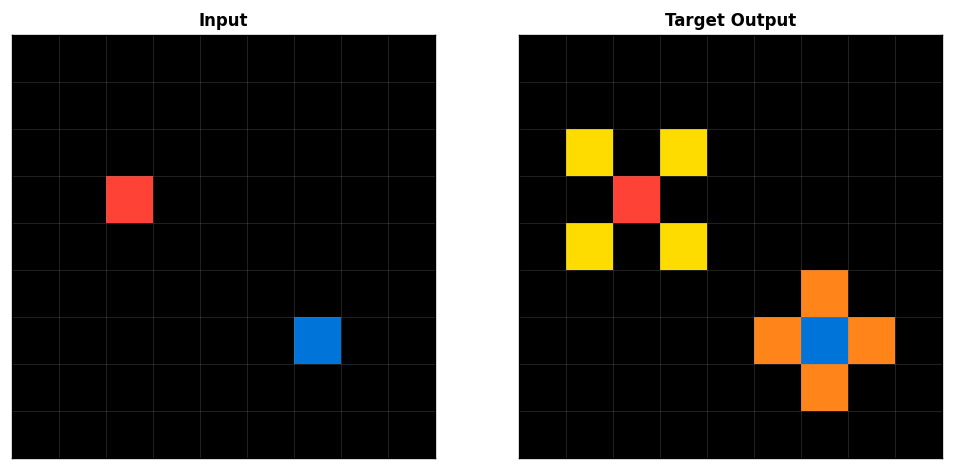

In [3]:
with open('/kaggle/input/competitions/neurogolf-2026/task015.json') as f:
    task = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_arc_grid(task['train'][0]['input'], axes[0], 'Input')
plot_arc_grid(task['train'][0]['output'], axes[1], 'Target Output')
plt.show()

# 2. Convolution design

In ONNX, the `Conv` operator weights W have the shape **[M, C, kH, kW]**:
- `M` = number of **output** channels (10, one per color)
- `C` = number of **input** channels (10, one per color)
- `kH, kW` = kernel height and width (both 3 in this case)

This means that every input color (0-9) can influence every output color (0-9) through a unique 3x3 pattern of weights. We have 100 unique 3x3 patterns (10 output colors x 10 input colors).

### The 3×3 Stencil

When the convolution produces pixel `(x,y)` in the output, it looks at a 3×3 window of the input centered at `(x,y)`. The window coordinates (offset from center) are:

$$
\begin{bmatrix}
(-1,-1) & ( 0,-1) & ( 1,-1) \\
(-1, 0) & ( 0, 0) & ( 1, 0) \\
(-1, 1) & ( 0, 1) & ( 1, 1)
\end{bmatrix}
$$

The offset `(0,0)` is the **center** — the pixel directly below the output position. The other offsets are its neighbors.

### The Formula
The output for a color O at position (x,y) is:
$$ Output_{O}(x,y) = \sum_{i=0}^{9} \sum_{r=-1}^{1} \sum_{c=-1}^{1} Input_{i}(x+r, y+c) \cdot W(O, i, r, c) $$

## 2.1 The Identity Kernel — "Pixel stays where it is"

### The Identity Kernel

The simplest kernel is the **identity**: it copies an input pixel straight to the output without moving it. For every color `c`, we set:

$$W[c,\;c,\;1,\;1] = 1.0$$

This says: "for output channel `c`, look at input channel `c`, at offset `(0,0)` (the center), and multiply by 1.0." All other offsets are 0, so no neighboring pixels leak in.

Visually, the identity kernel for any color `c` looks like this:

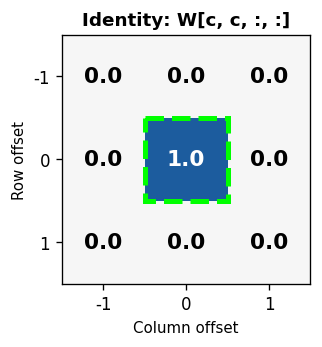

Only the center (0,0) is 1.0 — the pixel passes through unchanged.
All other offsets are 0.0 — no neighbor pixels bleed in.


In [4]:
def visualize_kernel(kernel, title, cmap='RdBu', highlight_center=True):
    fig, ax = plt.subplots(figsize=(3.5, 3))
    im = ax.imshow(kernel, cmap=cmap, vmin=-1.2, vmax=1.2)
    for i in range(3):
        for j in range(3):
            val = kernel[i, j]
            c = 'black' if abs(val) < 0.5 else 'white'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    color=c, fontweight='bold', fontsize=13)
    if highlight_center:
        ax.add_patch(plt.Rectangle((0.5, 0.5), 1, 1, fill=False,
                     edgecolor='lime', lw=3, linestyle='--'))
    ax.set_xticks(range(3), ['-1','0','1'])
    ax.set_yticks(range(3), ['-1','0','1'])
    ax.set_xlabel('Column offset', fontsize=9)
    ax.set_ylabel('Row offset', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

k_identity = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]])
visualize_kernel(k_identity, 'Identity: W[c, c, :, :]')

print("Only the center (0,0) is 1.0 — the pixel passes through unchanged.")
print("All other offsets are 0.0 — no neighbor pixels bleed in.")

## 2.2 Red Triggers Yellow — Two Kernels for One Rule

Now the real work begins. The task rule is:

> **Every Red (2) pixel must have Yellow (4) pixels at its four diagonal corners.**

But there's a subtlety: what if a corner position was **Black (0)** background? The Yellow pixel needs to *replace* the Black. So we need:

1. **A "write Yellow" kernel** — when the center is Red, vote +1.0 for Yellow at the corners.
2. **A "suppress Black" kernel** — when the center is Red, vote −1.0 for Black at those same corners.

### The Two Corners Kernels

Both kernels use the same 3×3 pattern — the four corners — but with opposite signs.

| Kernel | Expression | Effect |
|--------|-----------|--------|
| `W[4, 2, :, :]` = corners pattern × **+1** | Each corner adds 1.0 to Yellow's score | **Creates** Yellow at the diagonals |
| `W[0, 2, :, :]` = corners pattern × **−1** | Each corner subtracts 1.0 from Black's score | **Suppresses** Black at those same spots |

The corners pattern is:

$$
\begin{bmatrix}
1 & 0 & 1 \\
0 & 0 & 0 \\
1 & 0 & 1
\end{bmatrix}
$$

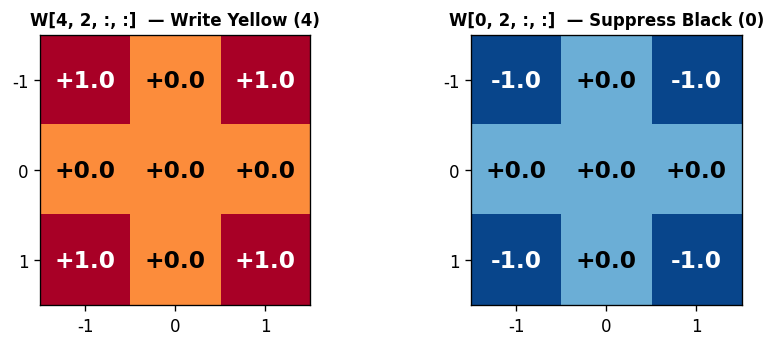

The two kernels are identical in pattern (corners), opposite in sign.
Together they ensure: when center is Red → corners become Yellow, not Black.


In [5]:
k_corners_pos = np.array([[ 1,  0,  1],
                          [ 0,  0,  0],
                          [ 1,  0,  1]])
k_corners_neg = np.array([[-1,  0, -1],
                          [ 0,  0,  0],
                          [-1,  0, -1]])

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3))
for ax, kernel, title, cm in zip(axes,
    [k_corners_pos, k_corners_neg],
    [r'W[4, 2, :, :]  — Write Yellow (4)', r'W[0, 2, :, :]  — Suppress Black (0)'],
    ['YlOrRd', 'Blues_r']):
    im = ax.imshow(kernel, cmap=cm, vmin=-1.2, vmax=1.2)
    for i in range(3):
        for j in range(3):
            val = kernel[i, j]
            c = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:+.1f}', ha='center', va='center',
                    color=c, fontweight='bold', fontsize=14)
    ax.set_xticks(range(3), ['-1','0','1'])
    ax.set_yticks(range(3), ['-1','0','1'])
    ax.set_title(title, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("The two kernels are identical in pattern (corners), opposite in sign.")
print("Together they ensure: when center is Red → corners become Yellow, not Black.")

### How the Convolution "Walks" Across the Grid
Let's trace what the convolution computes at **three different output positions** on a 5×5 grid with a single Red at (2,2).

We fix $W[4, 3, :, :]$ and for each position we show:
1. **Where the kernel is centered** — first column — marked with an orange square on the input grid
2. **What the 3×3 kernel "sees"** — second column — each cell shows the input pixel color AND the weight value for (input→output) at that offset
3. **The score breakdown** — third column — how each channel's score is computed, and which wins

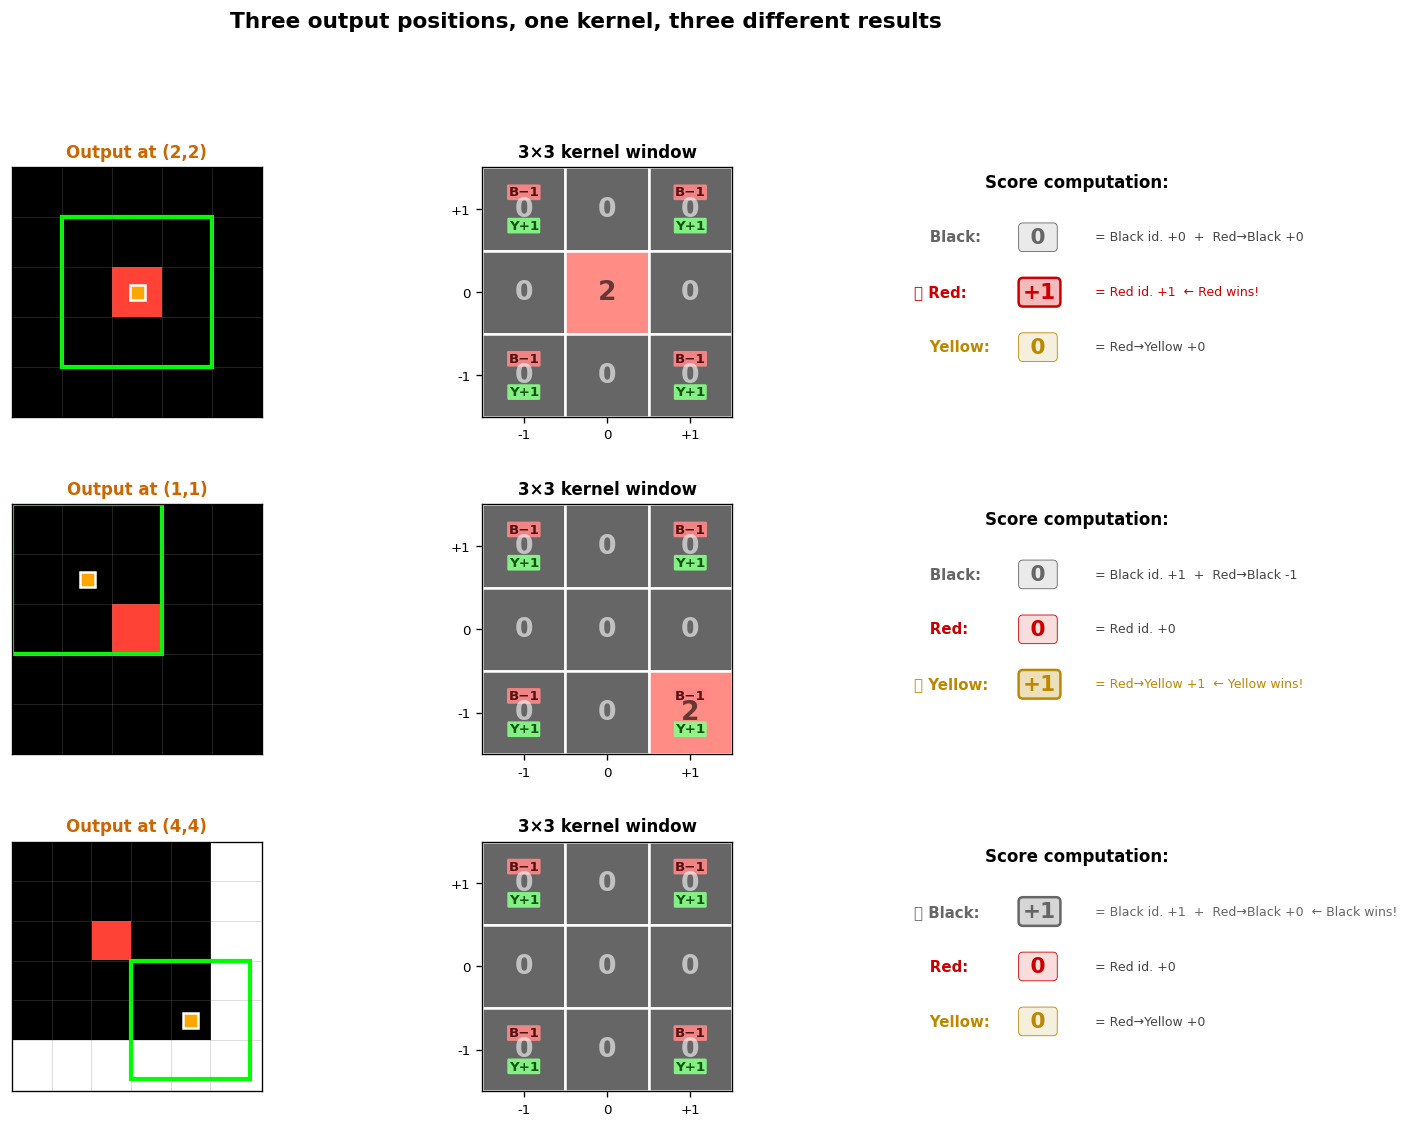

In [6]:
# Simplified weight patterns
W_identity = np.array([[0,0,0],[0,1,0],[0,0,0]])       # W[c,c,:,:]
W_corners_pos = np.array([[1,0,1],[0,0,0],[1,0,1]])    # W[4,2,:,:]: +1 at corners
W_corners_neg = np.array([[-1,0,-1],[0,0,0],[-1,0,-1]]) # W[0,2,:,:]: -1 at corners

grid = [[0]*5 for _ in range(5)]
grid[2][2] = 2  # Red at center

W_pos_colors = {1: ('#22AA22', 'white'), -1: ('#CC3333', 'white'), 0: ('none', 'none')}

def compute_scores_at(out_y, out_x):
    """Simulate Conv at (out_y, out_x). Returns (scores_dict, input_tile)."""
    score_black, score_red, score_yellow = 0.0, 0.0, 0.0
    tile = [[None]*3 for _ in range(3)]
    for dy in range(3):
        for dx in range(3):
            iy, ix = out_y - 1 + dy, out_x - 1 + dx  # with pads=[1,1,1,1]
            ch = grid[iy][ix] if (0 <= iy < 5 and 0 <= ix < 5) else 0
            tile[dy][dx] = ch

            if ch == 2:
                score_red += W_identity[dy, dx]
                score_yellow += W_corners_pos[dy, dx]
                score_black += W_corners_neg[dy, dx]
            elif ch == 0:
                score_black += W_identity[dy, dx]
    return {'Black': score_black, 'Red': score_red, 'Yellow': score_yellow}, tile


def draw_weight_cell(ax, dy, dx, ch, W_yellow_val, W_black_val):
    """Draw one cell of the 3x3 zoom: background = input color, text = weights."""
    # Background: input pixel color
    hex_c = arc_colors[ch].lstrip('#')
    bg = np.array([int(hex_c[i:i+2], 16) for i in (0, 2, 4)])
    # Lighten it a bit
    bg = (bg * 0.6 + np.array([255, 255, 255]) * 0.4).astype(np.uint8)
    ax.fill_between([dx-0.5, dx+0.5], dy-0.5, dy+0.5, color=bg/255, ec='white', lw=1.5)

    # Top line: +1 weights (W[4,2] create Yellow)
    if W_yellow_val == 1:
        ax.text(dx, dy-0.2, 'Y+1', ha='center', va='center', fontsize=8,
                fontweight='bold', color='#115511',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='#88FF88', alpha=0.9, ec='none'))

    # Bottom line: -1 weights (W[0,2] suppress Black)
    if W_black_val == -1:
        ax.text(dx, dy+0.2, 'B\u22121', ha='center', va='center', fontsize=8,
                fontweight='bold', color='#551111',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='#FF8888', alpha=0.9, ec='none'))

    # Show input channel number in center
    ch_color = 'white' if ch in (0, 9) else 'black'
    ax.text(dx, dy, str(ch), ha='center', va='center', fontsize=16,
            fontweight='bold', color=ch_color, alpha=0.6)


cases = [
    (2, 2, 'Kernel centered ON Red'),
    (1, 1, 'Kernel centered at corner (1,1)'),
    (4, 4, 'Kernel centered at (4,4), far from Red'),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.subplots_adjust(hspace=0.35, wspace=0.3)

for case_idx, (oy, ox, case_title) in enumerate(cases):
    scores, tile = compute_scores_at(oy, ox)

    # --- Column 1: full input grid with marker ---
    ax = axes[case_idx, 0]
    plot_arc_grid(grid, ax)
    rect = patches.Rectangle((ox-1.5, oy-1.5), 3, 3, linewidth=2.5,
                              edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.plot(ox, oy, marker='s', color='orange', markersize=9,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.set_title(f'Output at ({oy},{ox})', fontsize=10, fontweight='bold', color='#CC6600')

    # --- Column 2: zoomed 3x3 window with weights ---
    ax = axes[case_idx, 1]
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['-1','0','+1']); ax.set_yticklabels(['-1','0','+1'])
    ax.tick_params(labelsize=8)

    for dy in range(3):
        for dx in range(3):
            # Note: matrix (dy,dx) vs plot (x=dx, y=dy) — matplotlib uses (x,y)
            ch = tile[2-dy][dx] if tile[2-dy][dx] is not None else 0  # flip y for visual
            # Actually, tile[dy][dx] is already row dy, so in plot coords it's y=dy, x=dx
            # Just need to invert y for display since images have y=0 at top
            draw_weight_cell(ax, 2-dx, dy, tile[dy][dx],
                           W_corners_pos[dy, dx], W_corners_neg[dy, dx])

    ax.set_title('3\u00d73 kernel window', fontsize=10, fontweight='bold')

    # --- Column 3: score breakdown ---
    ax = axes[case_idx, 2]
    ax.axis('off')

    # Compute per-channel contributions
    contrib_black = {'identity': 0.0, 'suppress_from_red': 0.0}
    contrib_red = {'identity': 0.0}
    contrib_yellow = {'create_from_red': 0.0}
    for dy in range(3):
        for dx in range(3):
            ch = tile[dy][dx]
            if ch == 2:
                contrib_red['identity'] += W_identity[dy, dx]
                contrib_yellow['create_from_red'] += W_corners_pos[dy, dx]
                contrib_black['suppress_from_red'] += W_corners_neg[dy, dx]
            elif ch == 0:
                contrib_black['identity'] += W_identity[dy, dx]

    ax.text(0.5, 0.92, 'Score computation:', ha='center', fontsize=10, fontweight='bold')

    lines = [
        ('Black',  scores['Black'],
         f"Black id. {contrib_black['identity']:+.0f}  +  Red\u2192Black {contrib_black['suppress_from_red']:+.0f}",
         '#666666'),
        ('Red',    scores['Red'],
         f"Red id. {contrib_red['identity']:+.0f}",
         '#CC0000'),
        ('Yellow', scores['Yellow'],
         f"Red\u2192Yellow {contrib_yellow['create_from_red']:+.0f}",
         '#BB8800'),
    ]

    winner_name = max(scores, key=scores.get)
    for i, (name, total, formula, c) in enumerate(lines):
        y_pos = 0.72 - i * 0.22
        is_winner = (name == winner_name)
        marker = '\u2b50' if is_winner else '  '
        total_str = f'{total:+.0f}' if total != 0 else ' 0 '
        winner_label = f'  \u2190 {name} wins!' if is_winner else ''

        # Total score (bold)
        ax.text(0.05, y_pos, f'{marker} {name}:', fontsize=9, color=c, fontweight='bold', va='center')
        ax.text(0.35, y_pos, total_str, fontsize=13, color=c, fontweight='bold', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=c+'22' if not is_winner else c+'44',
                         ec=c, lw=1.5 if is_winner else 0.5))
        ax.text(0.55, y_pos, f'= {formula}{winner_label}', fontsize=7.5,
                color='#444444' if not is_winner else c, va='center')

fig.suptitle('Three output positions, one kernel, three different results',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

## 2.3 Blue Triggers Orange — Same Strategy, Different Pattern

The second rule is:

> **Every Blue (1) pixel must have Orange (7) pixels at its Top, Bottom, Left, and Right (a cross shape).**

Same logic as Red → Yellow, but with a different 3×3 stencil: the **cross** instead of the corners.

| Kernel | Expression | Effect |
|--------|-----------|--------|
| `W[7, 1, :, :]` = cross pattern × **+1** | Each cross arm adds 1.0 to Orange's score | **Creates** Orange in the cardinal directions |
| `W[0, 1, :, :]` = cross pattern × **−1** | Each cross arm subtracts 1.0 from Black's score | **Suppresses** Black at those same spots |

The cross pattern is:
$$
\begin{bmatrix}
0 & 1 & 0 \\
1 & 0 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$


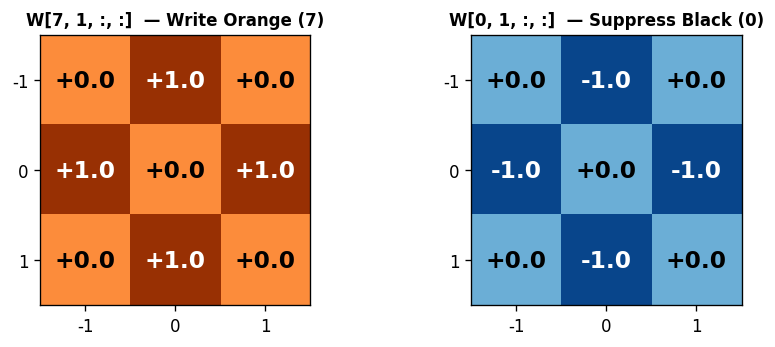

Blue at center → Orange created at cross positions, Black suppressed there.


In [7]:
k_cross_pos = np.array([[ 0,  1,  0],
                        [ 1,  0,  1],
                        [ 0,  1,  0]])
k_cross_neg = np.array([[ 0, -1,  0],
                        [-1,  0, -1],
                        [ 0, -1,  0]])

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3))
for ax, kernel, title, cm in zip(axes,
    [k_cross_pos, k_cross_neg],
    [r'W[7, 1, :, :]  — Write Orange (7)', r'W[0, 1, :, :]  — Suppress Black (0)'],
    ['Oranges', 'Blues_r']):
    im = ax.imshow(kernel, cmap=cm, vmin=-1.2, vmax=1.2)
    for i in range(3):
        for j in range(3):
            val = kernel[i, j]
            c = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:+.1f}', ha='center', va='center',
                    color=c, fontweight='bold', fontsize=14)
    ax.set_xticks(range(3), ['-1','0','1'])
    ax.set_yticks(range(3), ['-1','0','1'])
    ax.set_title(title, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("Blue at center → Orange created at cross positions, Black suppressed there.")

## 2.4 Putting It All Together — Constructing the Model

We have now defined **five** distinct 3×3 kernels:

| # | From | To | Pattern | Weight | Purpose |
|---|------|----|---------|--------|---------|
| 1 | Any color `c` | Same color `c` | Center (0,0) only | +1.0 | **Identity** — pixel stays |
| 2 | Red (2) | Yellow (4) | Corners | +1.0 | Create Yellow at diagonals |
| 3 | Red (2) | Black (0) | Corners | −1.0 | Suppress Black at diagonals |
| 4 | Blue (1) | Orange (7) | Cross | +1.0 | Create Orange at cardinal dirs |
| 5 | Blue (1) | Black (0) | Cross | −1.0 | Suppress Black at cardinal dirs |

**All other (input, output) pairs are zero — no other color influences another.**

When we run the convolution, each output channel accumulates votes from all input channels. The final output is processed in a way that all elements grather than zero becomes $1.0$ and all the others becomes $0.0$.

In [8]:
def create_task015_model():
    W = np.zeros((10, 10, 3, 3), dtype=np.float32)
    # 1. Identity for all colors
    for c in range(10):
        W[c, c, 1, 1] = 1.0
    # 2. Red (2) -> Yellow (4) at corners
    for r, c in [(0,0), (0,2), (2,0), (2,2)]:
        W[4, 2, r, c] = 1.0
        W[0, 2, r, c] = -1.0
    # 3. Blue (1) -> Orange (7) at cross
    for r, c in [(0,1), (2,1), (1,0), (1,2)]:
        W[7, 1, r, c] = 1.0
        W[0, 1, r, c] = -1.0
    input_info = helper.make_tensor_value_info('input', TensorProto.FLOAT, [1, 10, 30, 30])
    output_info = helper.make_tensor_value_info('output', TensorProto.FLOAT, [1, 10, 30, 30])
    W_init = helper.make_tensor('W', TensorProto.FLOAT, [10, 10, 3, 3], W.flatten())
    conv_node = helper.make_node('Conv', ['input', 'W'], ['output'], kernel_shape=[3, 3], pads=[1, 1, 1, 1])
    graph = helper.make_graph([conv_node], 'task015', [input_info], [output_info], [W_init])
    model = helper.make_model(graph, opset_imports=[helper.make_operatorsetid('', 11)])
    return model

model = create_task015_model()
onnx.save(model, 'task015_demo.onnx')

# 3. Running the Model
Let's run the model on a test case.

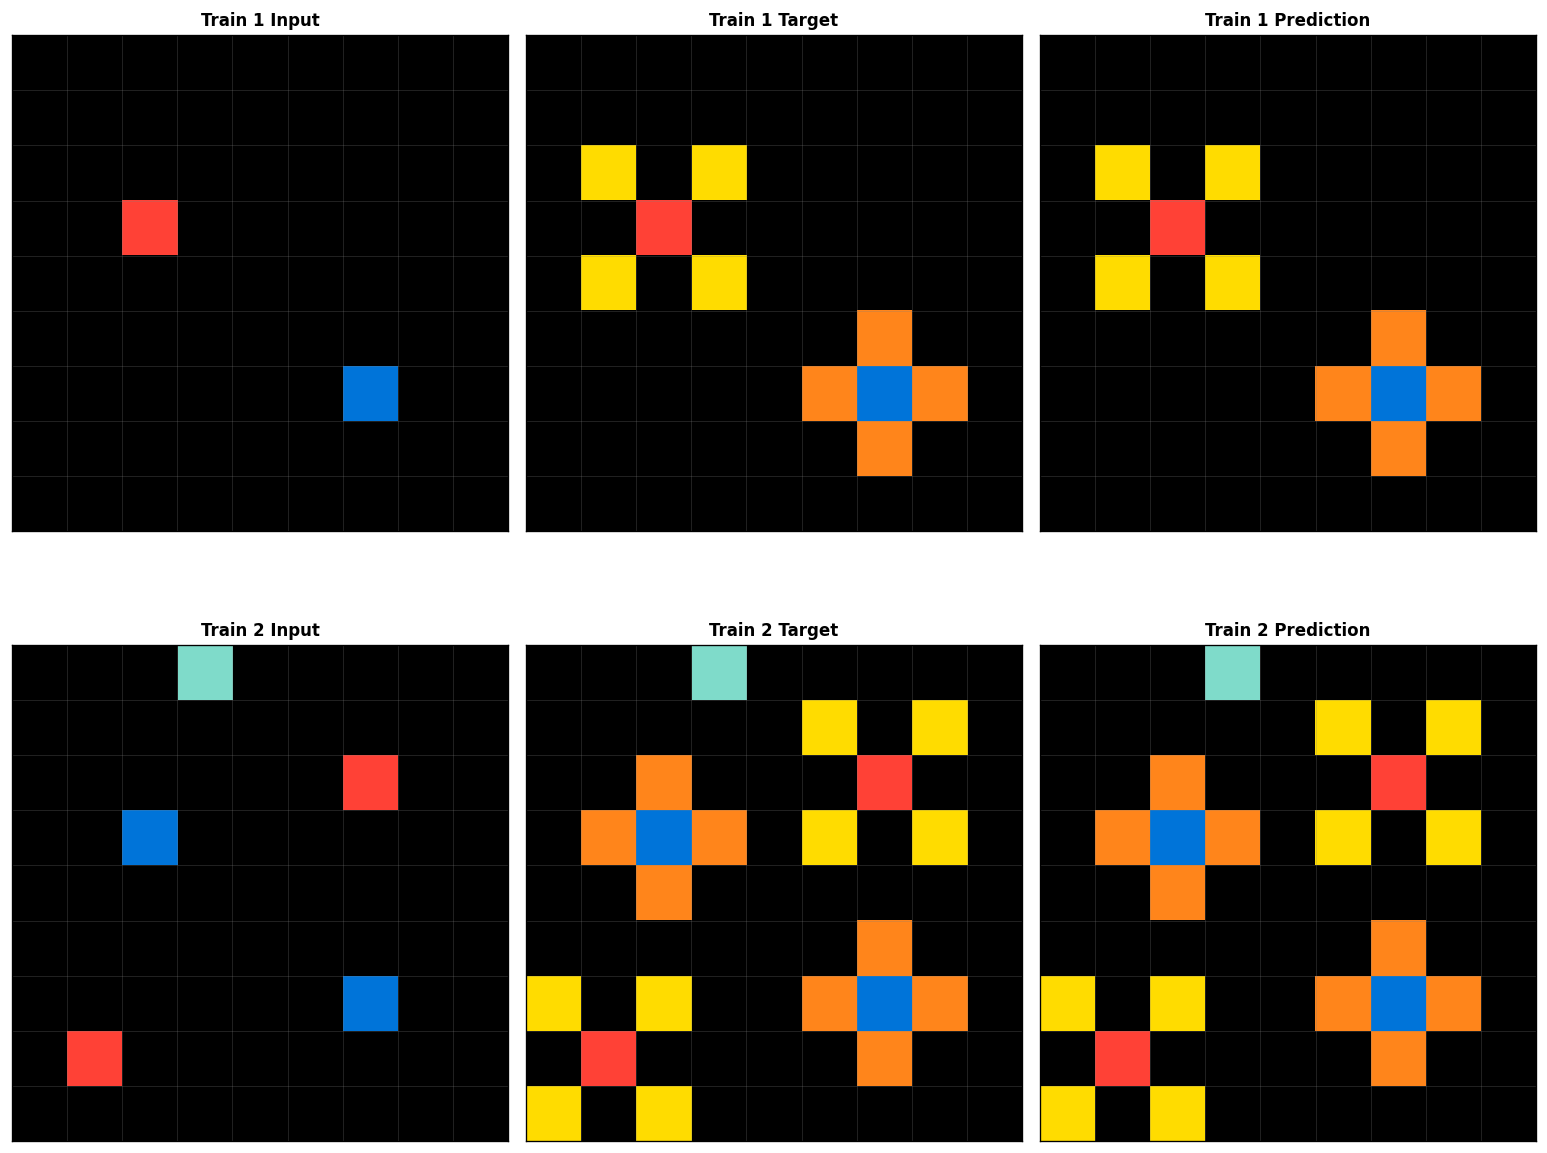

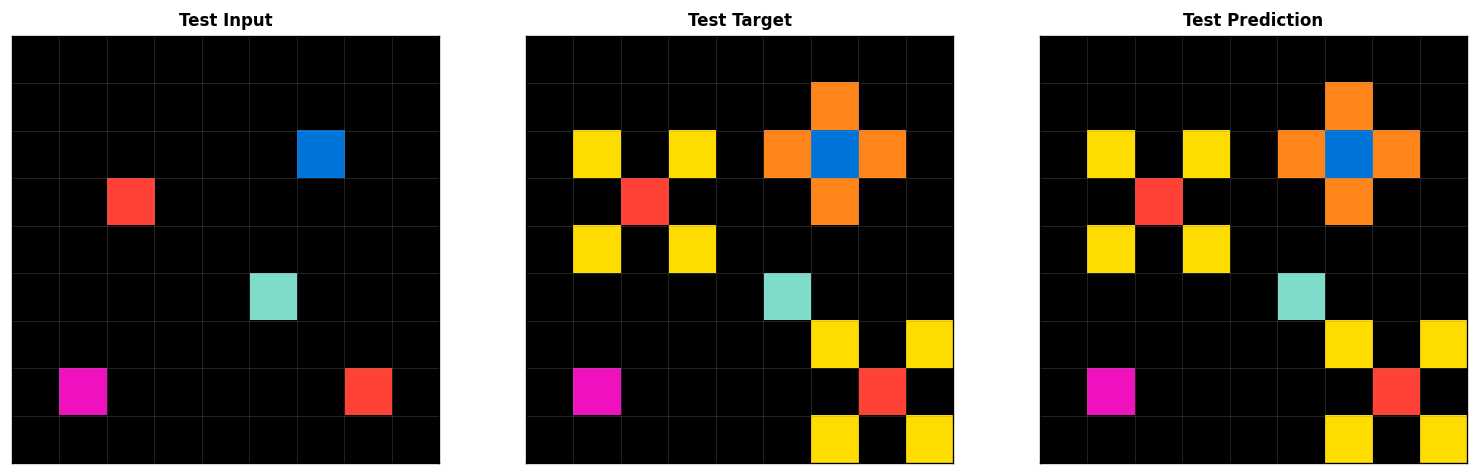

Results on ARC-AGI examples: 4 pass, 0 fail
Results on ARC-GEN examples: 261 pass, 0 fail

Your network IS READY for submission!

Performance stats (memory values reported here are approximate):
Name    Type    Forward_MACs    FPercent    Memory    MPercent      Params  PPercent    InShape     OutShape
------  ------  --------------  ----------  --------  ----------  --------  ----------  ----------  ----------
Conv_0  Conv    810,000         100.00%     39,600    100.00%          900  100.00%     1x10x30x30  1x10x30x30
Total   _       810,000         100%        39,600    100%             900  100%        _           _

It appears to require 0 bytes + 900 params, yielding 18.198 points.

Next steps:
 * Click the link below to download task015.onnx onto your local machine.
 * Create a zip file containing that network along with all others.
 * Submit that zip file to the Kaggle competition so that it can be officially scored.



/kaggle/working/task015.onnx

In [9]:
import sys
sys.path.append("/kaggle/input/competitions/neurogolf-2026/neurogolf_utils")
from neurogolf_utils import *

def run_inference(grid, model_path):
    oh = np.zeros((1, 10, 30, 30), dtype=np.float32)
    for r in range(len(grid)):
        for c in range(len(grid[0])):
            oh[0, grid[r][c], r, c] = 1.0
    sess = ort.InferenceSession(model_path)
    out = sess.run(None, {'input': oh})[0]
    return np.argmax(out[0], axis=0)

# Test on all train examples
fig, axes = plt.subplots(2, 3, figsize=(13, 11))
for i in range(2):
    inp = task['train'][i]['input']
    target = task['train'][i]['output']
    pred = run_inference(inp, 'task015_demo.onnx')
    H, W = len(inp), len(inp[0])
    plot_arc_grid(inp, axes[i, 0], f'Train {i+1} Input')
    plot_arc_grid(target, axes[i, 1], f'Train {i+1} Target')
    plot_arc_grid(pred[:H, :W], axes[i, 2], f'Train {i+1} Prediction')
plt.tight_layout()
plt.show()

# Test on test example
test_inp = task['test'][0]['input']
test_tgt = task['test'][0]['output']
test_pred = run_inference(test_inp, 'task015_demo.onnx')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_arc_grid(test_inp, axes[0], 'Test Input')
plot_arc_grid(test_tgt, axes[1], 'Test Target')
plot_arc_grid(test_pred[:len(test_inp), :len(test_inp[0])], axes[2], 'Test Prediction')
plt.tight_layout()
plt.show()

# Verify with official checker
passed = verify_network(model, 15, task)

# 4. Beyond Hand-Design: Task 151 and the Bias Term

Not all ARC tasks have rules as clean as task 015. Consider **task 151**: whenever a vertical line crosses a horizontal line, a 3×3 Yellow block appears around the intersection, but the center pixel keeps its original color.

**Our result:** Mem=0, Params=910, **18.187 points**

Let's look at some examples:

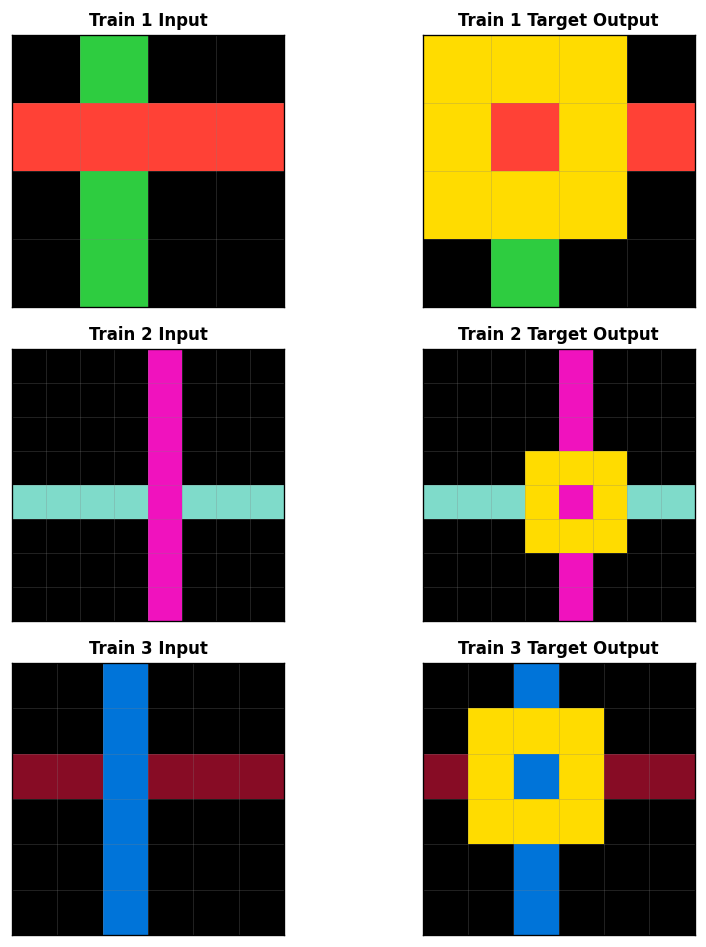

In [10]:
with open('/kaggle/input/competitions/neurogolf-2026/task151.json') as f:
    task151 = json.load(f)

fig, axes = plt.subplots(3, 2, figsize=(8, 8))
for i in range(3):
    plot_arc_grid(task151['train'][i]['input'], axes[i, 0], f'Train {i+1} Input')
    plot_arc_grid(task151['train'][i]['output'], axes[i, 1], f'Train {i+1} Target Output')
plt.tight_layout()
plt.show()

Notice the pattern: there is always a vertical line of one color and a horizontal line of another. Where they intersect, a 3×3 Yellow block appears, but the center pixel keeps its original line color.

This is still solvable with a **single 3×3 Conv** — the same architecture as task 015! — but the weights are no longer simple $\pm 1.0$ patterns. Instead, we train the convolution, and the resulting weights are floating-point values.

### What is the Bias?

In a standard Conv, each output channel also gets a **bias** term — a single scalar added to every pixel of that output channel:

$$\text{Output}_c(x, y) = \sum_{i=0}^{9} \sum_{r=-1}^{1} \sum_{c=-1}^{1} \text{Input}_i(x+r, y+c) \cdot W_c[i, r, c] \; + \; \text{Bias}[c]$$

The bias shifts the *baseline activation* for a channel. In task 015 we had no bias (it defaults to 0), for task 151, we need to introduce them.

### Building and Running the Task 151 Model

The only difference from task 015 is that we pass `"B"` as the third input to the Conv node, and include the bias tensor in the initializers. The trained kernel weights replace our hand-crafted ±1.0 patterns.

In [11]:
# Build the task151 model using trained weights from src/task151.py
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Copy the model-building code from src/task151.py
W = np.zeros((10, 10, 3, 3), dtype=np.float32)
W[0, 0, 1, 1] = 0.03999999911
W[0, 1, 0, 1] = -0.01999999955
W[0, 1, 1, 0] = -0.01999999955
W[0, 1, 1, 2] = -0.01999999955
W[0, 1, 2, 1] = -0.01999999955
W[0, 2, 0, 1] = -0.01999999955
W[0, 2, 1, 0] = -0.01999999955
W[0, 2, 1, 2] = -0.01999999955
W[0, 2, 2, 1] = -0.01999999955
W[0, 3, 0, 1] = -0.01999999955
W[0, 3, 1, 0] = -0.01999999955
W[0, 3, 1, 2] = -0.01999999955
W[0, 3, 2, 1] = -0.01999999955
W[0, 5, 0, 1] = -0.01999999955
W[0, 5, 1, 0] = -0.01999999955
W[0, 5, 1, 2] = -0.01999999955
W[0, 5, 2, 1] = -0.01999999955
W[0, 6, 0, 1] = -0.01999999955
W[0, 6, 1, 0] = -0.01999999955
W[0, 6, 1, 2] = -0.01999999955
W[0, 6, 2, 1] = -0.01999999955
W[0, 7, 0, 1] = -0.01999999955
W[0, 7, 1, 0] = -0.01999999955
W[0, 7, 1, 2] = -0.01999999955
W[0, 7, 2, 1] = -0.01999999955
W[0, 8, 0, 1] = -0.01999999955
W[0, 8, 1, 0] = -0.01999999955
W[0, 8, 1, 2] = -0.01999999955
W[0, 8, 2, 1] = -0.01999999955
W[0, 9, 0, 1] = -0.01999999955
W[0, 9, 1, 0] = -0.01999999955
W[0, 9, 1, 2] = -0.01999999955
W[0, 9, 2, 1] = -0.01999999955
W[1, 1, 1, 1] = 0.01999999955
W[1, 2, 0, 0] = -0.01999999955
W[1, 2, 2, 2] = -0.01999999955
W[1, 3, 0, 2] = -0.01999999955
W[1, 3, 2, 0] = -0.01999999955
W[1, 5, 0, 0] = -0.01999999955
W[1, 5, 2, 2] = -0.01999999955
W[1, 6, 0, 2] = -0.01999999955
W[1, 6, 2, 0] = -0.01999999955
W[1, 7, 0, 2] = -0.01999999955
W[1, 7, 2, 0] = -0.01999999955
W[1, 8, 0, 0] = -0.01999999955
W[1, 8, 2, 2] = -0.01999999955
W[1, 9, 0, 0] = -0.01999999955
W[1, 9, 2, 2] = -0.01999999955
W[2, 1, 0, 2] = -0.01999999955
W[2, 1, 2, 0] = -0.01999999955
W[2, 2, 1, 1] = 0.01999999955
W[2, 3, 0, 0] = -0.01999999955
W[2, 3, 2, 2] = -0.01999999955
W[2, 5, 0, 2] = -0.01999999955
W[2, 5, 2, 0] = -0.01999999955
W[2, 6, 0, 2] = -0.01999999955
W[2, 6, 2, 0] = -0.01999999955
W[2, 7, 0, 0] = -0.01999999955
W[2, 7, 2, 2] = -0.01999999955
W[2, 8, 0, 2] = -0.01999999955
W[2, 8, 2, 0] = -0.01999999955
W[2, 9, 0, 2] = -0.01999999955
W[2, 9, 2, 0] = -0.01999999955
W[3, 1, 0, 2] = -0.01999999955
W[3, 1, 2, 0] = -0.01999999955
W[3, 2, 0, 2] = -0.01999999955
W[3, 2, 2, 0] = -0.01999999955
W[3, 3, 1, 1] = 0.01999999955
W[3, 5, 0, 0] = -0.01999999955
W[3, 5, 2, 2] = -0.01999999955
W[3, 6, 0, 0] = -0.01999999955
W[3, 6, 2, 2] = -0.01999999955
W[3, 7, 0, 0] = -0.01999999955
W[3, 7, 2, 2] = -0.01999999955
W[3, 8, 0, 2] = -0.01999999955
W[3, 8, 2, 0] = -0.01999999955
W[3, 9, 0, 0] = -0.01999999955
W[3, 9, 2, 2] = -0.01999999955
W[4, 0, 0, 0] = -0.006666666828
W[4, 0, 0, 1] = -0.02333333343
W[4, 0, 0, 2] = -0.006666666828
W[4, 0, 1, 0] = -0.02333333343
W[4, 0, 1, 1] = -0.003333333414
W[4, 0, 1, 2] = -0.02333333343
W[4, 0, 2, 0] = -0.006666666828
W[4, 0, 2, 1] = -0.02333333343
W[4, 0, 2, 2] = -0.006666666828
W[4, 1, 0, 0] = 0.02666666731
W[4, 1, 0, 2] = 0.02666666731
W[4, 1, 1, 1] = 0.02999999933
W[4, 1, 2, 0] = 0.02666666731
W[4, 1, 2, 2] = 0.02666666731
W[4, 2, 0, 0] = 0.02666666731
W[4, 2, 0, 2] = 0.02666666731
W[4, 2, 1, 1] = 0.02999999933
W[4, 2, 2, 0] = 0.02666666731
W[4, 2, 2, 2] = 0.02666666731
W[4, 3, 0, 0] = 0.02666666731
W[4, 3, 0, 2] = 0.02666666731
W[4, 3, 1, 1] = 0.02999999933
W[4, 3, 2, 0] = 0.02666666731
W[4, 3, 2, 2] = 0.02666666731
W[4, 5, 0, 0] = 0.02666666731
W[4, 5, 0, 2] = 0.02666666731
W[4, 5, 1, 1] = 0.02999999933
W[4, 5, 2, 0] = 0.02666666731
W[4, 5, 2, 2] = 0.02666666731
W[4, 6, 0, 0] = 0.02666666731
W[4, 6, 0, 2] = 0.02666666731
W[4, 6, 1, 1] = 0.02999999933
W[4, 6, 2, 0] = 0.02666666731
W[4, 6, 2, 2] = 0.02666666731
W[4, 7, 0, 0] = 0.02666666731
W[4, 7, 0, 2] = 0.02666666731
W[4, 7, 1, 1] = 0.02999999933
W[4, 7, 2, 0] = 0.02666666731
W[4, 7, 2, 2] = 0.02666666731
W[4, 8, 0, 0] = 0.02666666731
W[4, 8, 0, 2] = 0.02666666731
W[4, 8, 1, 1] = 0.02999999933
W[4, 8, 2, 0] = 0.02666666731
W[4, 8, 2, 2] = 0.02666666731
W[4, 9, 0, 0] = 0.02666666731
W[4, 9, 0, 2] = 0.02666666731
W[4, 9, 1, 1] = 0.02999999933
W[4, 9, 2, 0] = 0.02666666731
W[4, 9, 2, 2] = 0.02666666731
W[5, 1, 0, 2] = -0.01999999955
W[5, 1, 2, 0] = -0.01999999955
W[5, 2, 0, 2] = -0.01999999955
W[5, 2, 2, 0] = -0.01999999955
W[5, 3, 0, 0] = -0.01999999955
W[5, 3, 2, 2] = -0.01999999955
W[5, 5, 1, 1] = 0.01999999955
W[5, 6, 0, 2] = -0.01999999955
W[5, 6, 2, 0] = -0.01999999955
W[5, 7, 0, 0] = -0.01999999955
W[5, 7, 2, 2] = -0.01999999955
W[5, 8, 2, 0] = -0.01999999955
W[5, 8, 2, 2] = -0.01999999955
W[5, 9, 0, 0] = -0.01999999955
W[5, 9, 2, 2] = -0.01999999955
W[6, 1, 0, 2] = -0.01999999955
W[6, 1, 2, 0] = -0.01999999955
W[6, 2, 0, 2] = -0.01999999955
W[6, 2, 2, 0] = -0.01999999955
W[6, 3, 0, 0] = -0.01999999955
W[6, 3, 2, 2] = -0.01999999955
W[6, 5, 0, 2] = -0.01999999955
W[6, 5, 2, 0] = -0.01999999955
W[6, 6, 1, 1] = 0.01999999955
W[6, 7, 0, 0] = -0.01999999955
W[6, 7, 2, 2] = -0.01999999955
W[6, 8, 0, 2] = -0.01999999955
W[6, 8, 2, 0] = -0.01999999955
W[6, 9, 0, 2] = -0.01999999955
W[6, 9, 2, 0] = -0.01999999955
W[7, 1, 0, 2] = -0.01999999955
W[7, 1, 2, 0] = -0.01999999955
W[7, 2, 0, 2] = -0.01999999955
W[7, 2, 2, 0] = -0.01999999955
W[7, 3, 0, 0] = -0.01999999955
W[7, 3, 2, 2] = -0.01999999955
W[7, 5, 0, 2] = -0.01999999955
W[7, 5, 2, 0] = -0.01999999955
W[7, 6, 0, 2] = -0.01999999955
W[7, 6, 2, 0] = -0.01999999955
W[7, 7, 1, 1] = 0.01999999955
W[7, 8, 0, 2] = -0.01999999955
W[7, 8, 2, 0] = -0.01999999955
W[7, 9, 0, 2] = -0.01999999955
W[7, 9, 2, 0] = -0.01999999955
W[8, 1, 0, 2] = -0.01999999955
W[8, 1, 2, 0] = -0.01999999955
W[8, 2, 0, 2] = -0.01999999955
W[8, 2, 2, 0] = -0.01999999955
W[8, 3, 0, 0] = -0.01999999955
W[8, 3, 2, 2] = -0.01999999955
W[8, 5, 0, 2] = -0.01999999955
W[8, 5, 2, 2] = -0.01999999955
W[8, 6, 0, 0] = -0.01999999955
W[8, 6, 2, 2] = -0.01999999955
W[8, 7, 0, 2] = -0.01999999955
W[8, 7, 2, 0] = -0.01999999955
W[8, 8, 1, 1] = 0.01999999955
W[8, 9, 0, 0] = -0.01999999955
W[8, 9, 2, 2] = -0.01999999955
W[9, 1, 0, 2] = -0.01999999955
W[9, 1, 2, 0] = -0.01999999955
W[9, 2, 0, 2] = -0.01999999955
W[9, 2, 2, 0] = -0.01999999955
W[9, 3, 0, 0] = -0.01999999955
W[9, 3, 2, 2] = -0.01999999955
W[9, 5, 0, 2] = -0.01999999955
W[9, 5, 2, 0] = -0.01999999955
W[9, 6, 0, 2] = -0.01999999955
W[9, 6, 2, 0] = -0.01999999955
W[9, 7, 0, 0] = -0.01999999955
W[9, 7, 2, 2] = -0.01999999955
W[9, 8, 0, 2] = -0.01999999955
W[9, 8, 2, 0] = -0.01999999955
W[9, 9, 1, 1] = 0.01999999955

B = np.array([-0.01, -0.01, -0.01, -0.01, -0.01333333333,
              -0.01, -0.01, -0.01, -0.01, -0.01], dtype=np.float32)

print("Bias vector (10 output channels):")
for i, (name, val) in enumerate(zip(
    ['black','blue','red','green','yellow','gray','magenta','orange','teal','maroon'], B)):
    print(f"  [{i}] {name:8s}: {val:+.4f}")

input_info = helper.make_tensor_value_info('input', TensorProto.FLOAT, [1, 10, 30, 30])
output_info = helper.make_tensor_value_info('output', TensorProto.FLOAT, [1, 10, 30, 30])
W_init = helper.make_tensor('W', TensorProto.FLOAT, [10, 10, 3, 3], W.flatten().tolist())
B_init = helper.make_tensor('B', TensorProto.FLOAT, [10], B.tolist())
conv_node = helper.make_node('Conv', ['input', 'W', 'B'], ['output'],
                             kernel_shape=[3, 3], pads=[1, 1, 1, 1])
graph = helper.make_graph([conv_node], 'task151', [input_info], [output_info], [W_init, B_init])
model151 = helper.make_model(graph, opset_imports=[helper.make_operatorsetid('', 11)])
onnx.save(model151, 'task151_demo.onnx')
print(f"\nTotal params: {900 + B.size} (900 weights + 10 biases)")

Bias vector (10 output channels):
  [0] black   : -0.0100
  [1] blue    : -0.0100
  [2] red     : -0.0100
  [3] green   : -0.0100
  [4] yellow  : -0.0133
  [5] gray    : -0.0100
  [6] magenta : -0.0100
  [7] orange  : -0.0100
  [8] teal    : -0.0100
  [9] maroon  : -0.0100

Total params: 910 (900 weights + 10 biases)


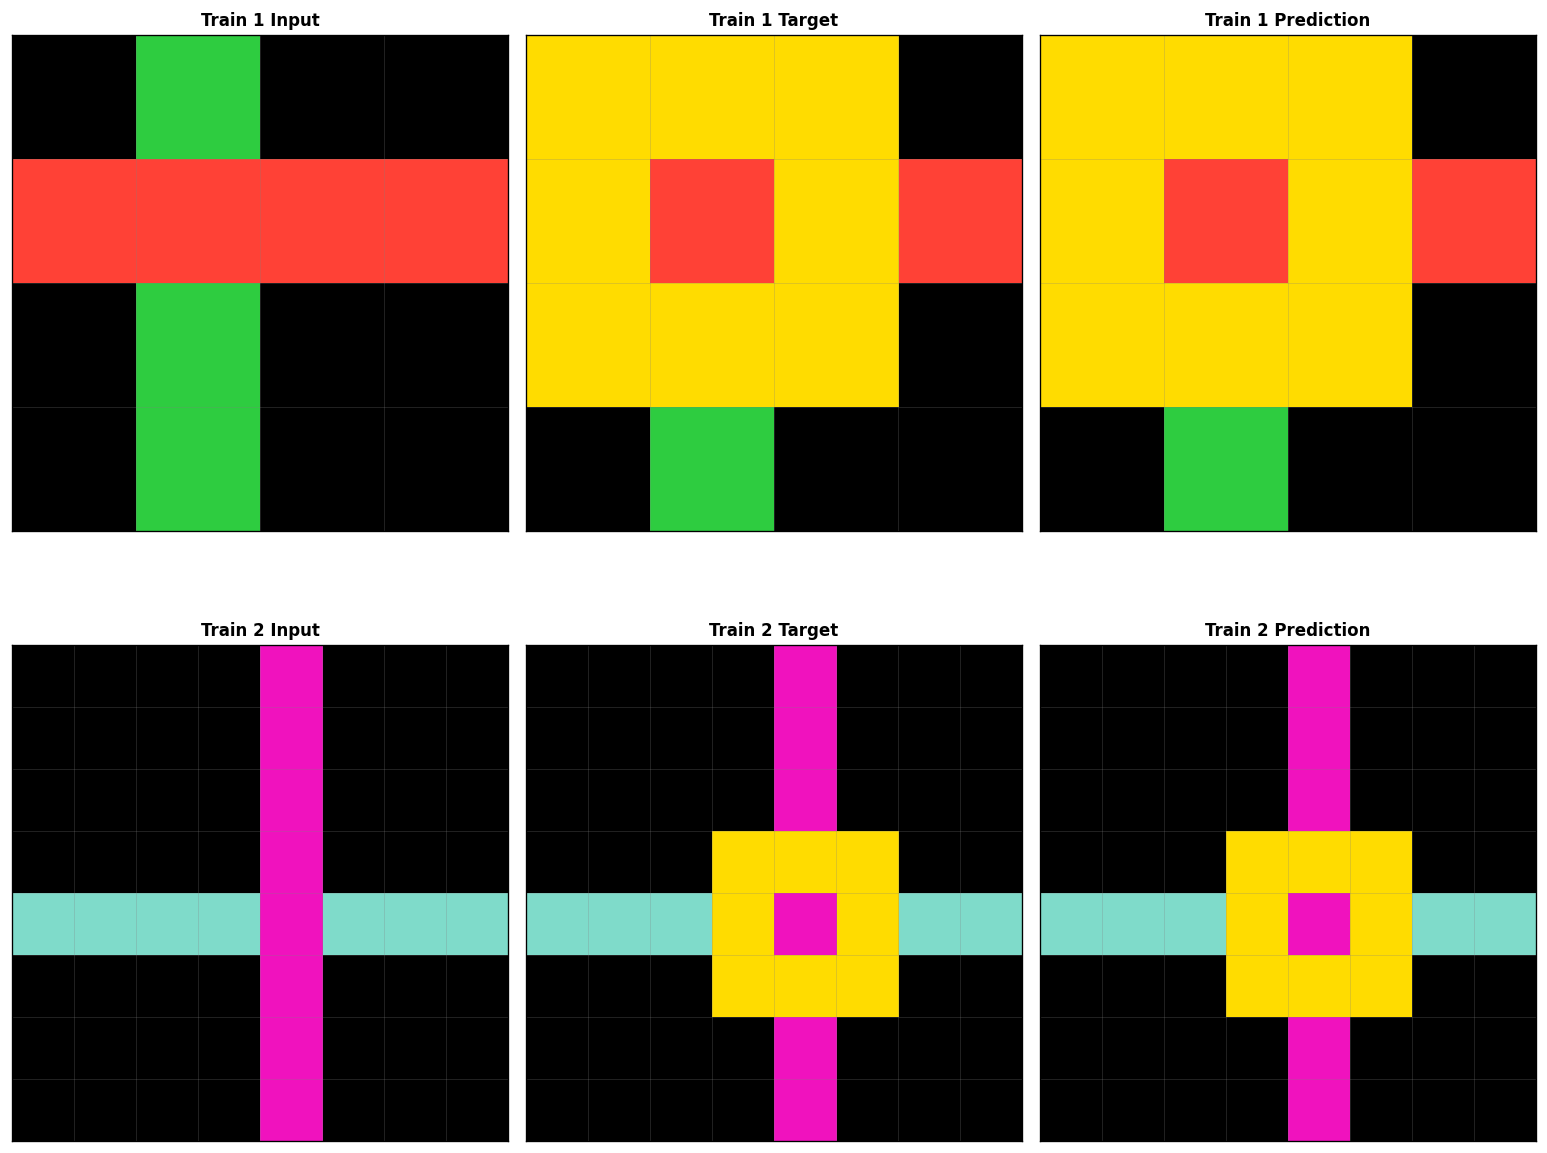

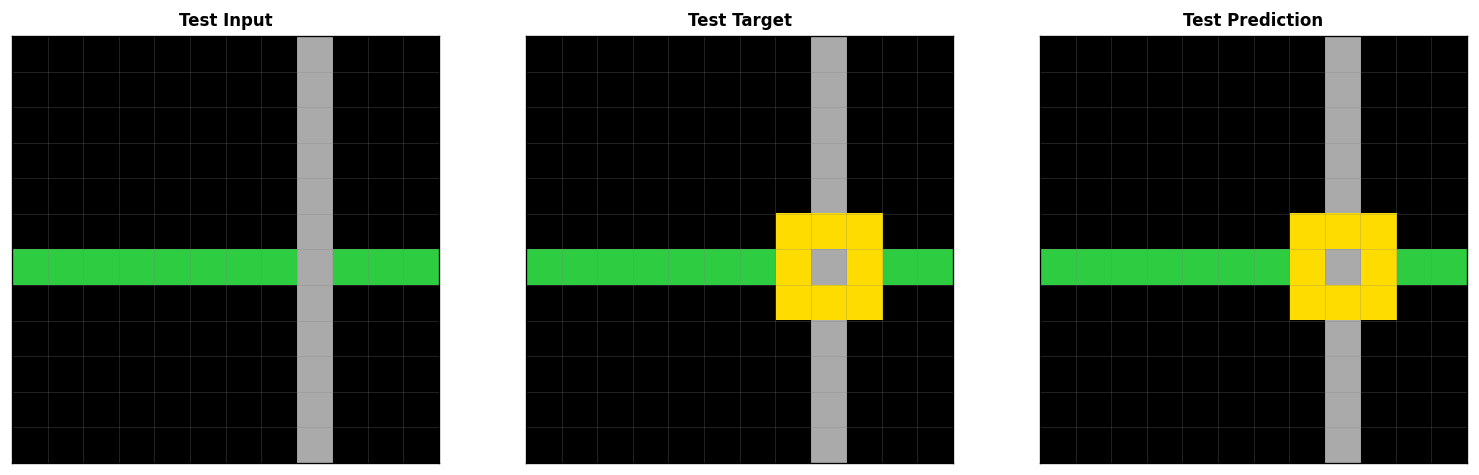

Results on ARC-AGI examples: 4 pass, 0 fail
Results on ARC-GEN examples: 262 pass, 0 fail

Your network IS READY for submission!

Performance stats (memory values reported here are approximate):
Name    Type    Forward_MACs    FPercent    Memory    MPercent      Params  PPercent    InShape     OutShape
------  ------  --------------  ----------  --------  ----------  --------  ----------  ----------  ----------
Conv_0  Conv    819,000         100.00%     39,640    100.00%          910  100.00%     1x10x30x30  1x10x30x30
Total   _       819,000         100%        39,640    100%             910  100%        _           _

It appears to require 0 bytes + 910 params, yielding 18.187 points.

Next steps:
 * Click the link below to download task151.onnx onto your local machine.
 * Create a zip file containing that network along with all others.
 * Submit that zip file to the Kaggle competition so that it can be officially scored.



/kaggle/working/task151.onnx

In [12]:
# Test on all train examples
fig, axes = plt.subplots(2, 3, figsize=(13, 11))
for i in range(2):
    inp = task151['train'][i]['input']
    target = task151['train'][i]['output']
    pred = run_inference(inp, 'task151_demo.onnx')
    H, W = len(inp), len(inp[0])
    plot_arc_grid(inp, axes[i, 0], f'Train {i+1} Input')
    plot_arc_grid(target, axes[i, 1], f'Train {i+1} Target')
    plot_arc_grid(pred[:H, :W], axes[i, 2], f'Train {i+1} Prediction')
plt.tight_layout()
plt.show()

# Test on test example
test_inp = task151['test'][0]['input']
test_tgt = task151['test'][0]['output']
test_pred = run_inference(test_inp, 'task151_demo.onnx')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_arc_grid(test_inp, axes[0], 'Test Input')
plot_arc_grid(test_tgt, axes[1], 'Test Target')
plot_arc_grid(test_pred[:len(test_inp), :len(test_inp[0])], axes[2], 'Test Prediction')
plt.tight_layout()
plt.show()

# Verify with official checker
passed = verify_network(model151, 151, task151)

# Summary
- **Spatial Locality:** Kernel size 3x3 is enough to detect a pixel and its neighbors.
- **Cross-Channel Power:** The 4D weights allow us to say 'If I see Color A, I should write Color B at this offset'.
- **Competition via Negative Weights:** For every 'create' kernel (+1.0 for the target color), we add a matching 'suppress' kernel (−1.0 for Black) so the new color wins against the background.
- **The Bias Term:** A learnable scalar per output channel that shifts the baseline activation. Used in trained models like task151 to fine-tune when a color activates.
- **Trained vs Hand-Designed:** Both task015 and task151 share the exact same Conv 3×3 architecture — the only difference is whether weights are hand-crafted or learned.

In [13]:
import shutil
import os
import zipfile

# --- CONFIGURATION ---
SOURCE_FOLDER = '/kaggle/input/datasets/massimilianoghiotto/neurogolf2026-6208/'
OUTPUT_ZIP = '/kaggle/working/submission.zip'

# Package the ZIP (Ensuring files are at the root)
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SOURCE_FOLDER):
        for file in files:
            if file.endswith('.onnx'):
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, SOURCE_FOLDER))

### **This is the best that we are able to do for the moment, if anyone has any suggestion, please write it in the comments, we are happy to have some brainstorning between people.**